# ACTIVIDAD 7
# NOMBRE: ISAAC JOEL MAMANI HUMPIRI

## 1. a. Use el dataset Iris y entrene los modelos K-means, DBSCAN y spectralClustering y aplique métricas de validación externa e interna.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Carga del conjunto de datos Iris y preprocesamiento
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Cargar dataset
iris = load_iris()
X = iris.data
y_true = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Estandarizar características (Media = 0, Varianza = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Importación de algoritmos de Clustering
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering

# Definición y entrenamiento de los modelos
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

spectral = SpectralClustering(n_clusters=3, random_state=42, assign_labels='kmeans')
labels_spectral = spectral.fit_predict(X_scaled)

# 3. Importación de Métricas de Validación Interna y Externa
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,  # Internas
    adjusted_rand_score, normalized_mutual_info_score, homogeneity_score  # Externas
)

models = {
    'K-Means (K=3)': labels_kmeans,
    'DBSCAN (eps=0.5, min=5)': labels_dbscan,
    'Spectral Clustering (K=3)': labels_spectral
}

# 4. Cálculo y Tabulación de Métricas
results = []

for name, labels in models.items():
    # Cantidad de clústeres detectados (excluyendo ruido -1 si aplica)
    n_clusters = len(set(labels) - {-1})

    # Métricas Internas (solo usan datos X y etiquetas predichas)
    if len(set(labels)) > 1:
        sil = silhouette_score(X_scaled, labels)
        ch = calinski_harabasz_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)
    else:
        sil, ch, db = np.nan, np.nan, np.nan

    # Métricas Externas (comparan etiquetas predichas vs etiquetas reales y_true)
    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)
    homog = homogeneity_score(y_true, labels)

    results.append({
        'Modelo': name,
        'Clústeres Detectados': n_clusters,
        'Silueta (Int)': round(sil, 4),
        'Calinski-Harabasz (Int)': round(ch, 2),
        'Davies-Bouldin (Int)': round(db, 4),
        'ARI (Ext)': round(ari, 4),
        'NMI (Ext)': round(nmi, 4),
        'Homogeneidad (Ext)': round(homog, 4)
    })

# Mostrar resultados en un DataFrame limpio
df_results = pd.DataFrame(results)
print("=== TABLA COMPARATIVA DE MÉTRICAS DE CLUSTERING (DATASET IRIS) ===")
display(df_results)

=== TABLA COMPARATIVA DE MÉTRICAS DE CLUSTERING (DATASET IRIS) ===


,Modelo,Clústeres Detectados,Silueta (Int),Calinski-Harabasz (Int),Davies-Bouldin (Int),ARI (Ext),NMI (Ext),Homogeneidad (Ext)
0,K-Means (K=3),3,0.4599,241.90,0.8336,0.6201,0.6595,0.6591
1,"DBSCAN (eps=0.5, min=5)",2,0.3565,84.51,7.1241,0.4421,0.5114,0.5005
2,Spectral Clustering (K=3),3,0.4630,236.89,0.8257,0.6451,0.6895,0.6824


Varianza explicada por PC1: 72.96%
Varianza explicada por PC2: 22.85%
Varianza acumulada: 95.81%


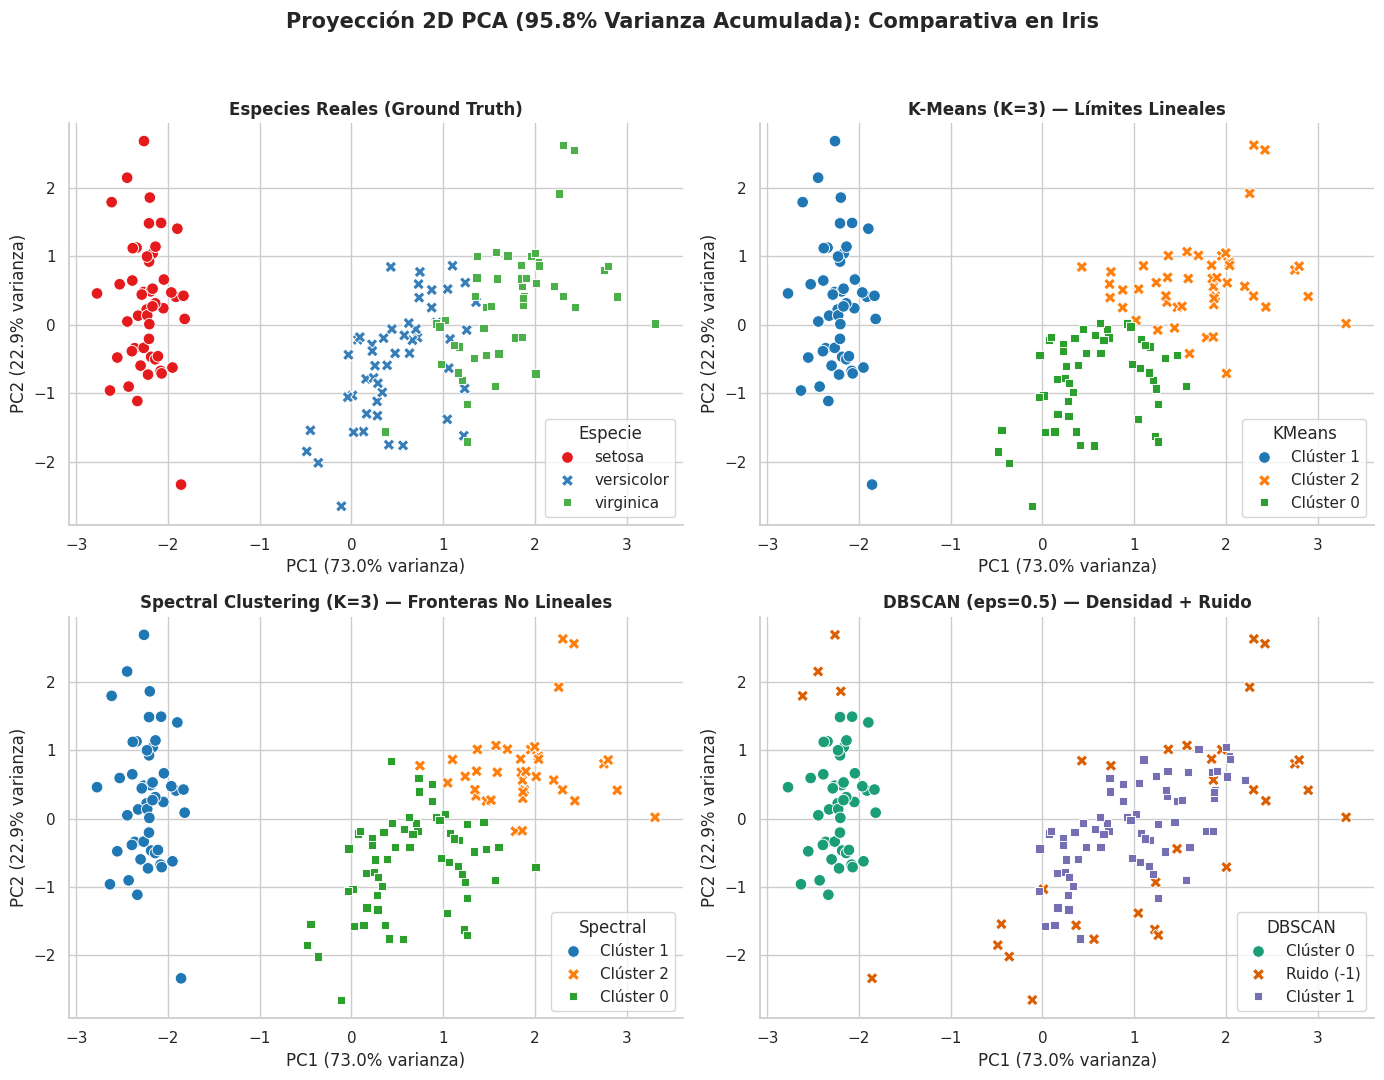

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering

# ============================================================
# 1. CARGAR Y ESTANDARIZAR DATOS
# ============================================================

iris = load_iris()

X = iris.data
y_true = iris.target
target_names = iris.target_names

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ============================================================
# 2. REDUCCIÓN DE DIMENSIONALIDAD CON PCA
# ============================================================

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_

print("Varianza explicada por PC1:", f"{var_exp[0]*100:.2f}%")
print("Varianza explicada por PC2:", f"{var_exp[1]*100:.2f}%")
print("Varianza acumulada:", f"{sum(var_exp)*100:.2f}%")


# ============================================================
# 3. ENTRENAR MODELOS DE CLUSTERING
# ============================================================

# K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)


# Spectral Clustering
spectral = SpectralClustering(
    n_clusters=3,
    random_state=42,
    assign_labels='kmeans'
)

spectral_labels = spectral.fit_predict(X_scaled)


# DBSCAN
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)


# ============================================================
# 4. CREAR DATAFRAME PARA LAS GRÁFICAS
# ============================================================

df_pca = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

df_pca['Especie'] = [
    target_names[i] for i in y_true
]

df_pca['KMeans'] = [
    f'Clúster {l}' for l in kmeans_labels
]

df_pca['Spectral'] = [
    f'Clúster {l}' for l in spectral_labels
]

df_pca['DBSCAN'] = [
    f'Clúster {l}' if l != -1 else 'Ruido (-1)'
    for l in dbscan_labels
]


# ============================================================
# 5. CONFIGURACIÓN DE ESTILO
# ============================================================

sns.set_theme(
    style='whitegrid',
    palette='colorblind'
)


# ============================================================
# 6. CREAR FIGURA 2x2
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 11)
)

fig.suptitle(
    f'Proyección 2D PCA ({sum(var_exp)*100:.1f}% Varianza Acumulada): Comparativa en Iris',
    fontsize=15,
    fontweight='bold'
)


# ============================================================
# 7. SUBPLOT 1 - ESPECIES REALES
# ============================================================

sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='Especie',
    style='Especie',
    s=70,
    ax=axes[0, 0],
    palette='Set1'
)

axes[0, 0].set_title(
    'Especies Reales (Ground Truth)',
    fontweight='bold'
)


# ============================================================
# 8. SUBPLOT 2 - K-MEANS
# ============================================================

sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='KMeans',
    style='KMeans',
    s=70,
    ax=axes[0, 1],
    palette='tab10'
)

axes[0, 1].set_title(
    'K-Means (K=3) — Límites Lineales',
    fontweight='bold'
)


# ============================================================
# 9. SUBPLOT 3 - SPECTRAL CLUSTERING
# ============================================================

sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='Spectral',
    style='Spectral',
    s=70,
    ax=axes[1, 0],
    palette='tab10'
)

axes[1, 0].set_title(
    'Spectral Clustering (K=3) — Fronteras No Lineales',
    fontweight='bold'
)


# ============================================================
# 10. SUBPLOT 4 - DBSCAN
# ============================================================

sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='DBSCAN',
    style='DBSCAN',
    s=70,
    ax=axes[1, 1],
    palette='Dark2'
)

axes[1, 1].set_title(
    'DBSCAN (eps=0.5) — Densidad + Ruido',
    fontweight='bold'
)


# ============================================================
# 11. ETIQUETAS DE EJES
# ============================================================

for ax in axes.flat:

    ax.set_xlabel(
        f'PC1 ({var_exp[0]*100:.1f}% varianza)'
    )

    ax.set_ylabel(
        f'PC2 ({var_exp[1]*100:.1f}% varianza)'
    )


# ============================================================
# 12. AJUSTAR DISEÑO
# ============================================================

sns.despine()

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()

## CONCLUSIÓN
### K-Means y Spectral Clustering:
Ambos logran un rendimiento alto en las métricas externas (ARI > 0.62 y NMI > 0.65) e internas (Silueta ~ 0.46)
. Esto confirma que los 3 clústeres encontrados corresponden estrechamente con las 3 especies biológicas de Iris
.
Spectral Clustering obtiene los mejores puntajes de coincidencia externa (ARI = 0.6451, NMI = 0.6895) gracias a su capacidad para capturar límites de separación no lineales entre las observaciones
.
### DBSCAN:
Al ejecutarse con eps=0.5, DBSCAN identifica solo 2 clústeres principales en lugar de 3.
Razón técnica: En el dataset Iris, la especie Setosa se encuentra totalmente aislada y linealmente separable de las demás. Sin embargo, las especies Versicolor y Virginica están muy densamente solapadas en el espacio continuo de 4 dimensiones
. Como DBSCAN agrupa por densidad de puntos, fusiona Versicolor y Virginica en un único clúster grande y clasifica los puntos más alejados como ruido
.

##1. B. Use el dataset sintético moons y entrene los modelos K-means, DBSCAN y SpectralClustering y aplique métricas de validación externa e interna.

RESULTADOS DE CLUSTERING - DATASET SINTÉTICO MOONS


,Modelo,Clústeres,Silueta (Int) ↑,Calinski-Harabasz (Int) ↑,Davies-Bouldin (Int) ↓,ARI (Ext) ↑,NMI (Ext) ↑,Homogeneidad (Ext) ↑
0,K-Means (K=2),2,0.4936,414.56,0.8056,0.479,0.3819,0.3819
1,DBSCAN (eps=0.3),2,0.3803,255.38,1.0252,1.000,1.0000,1.0000
2,Spectral Clustering (K=2),2,0.3803,255.38,1.0252,1.000,1.0000,1.0000


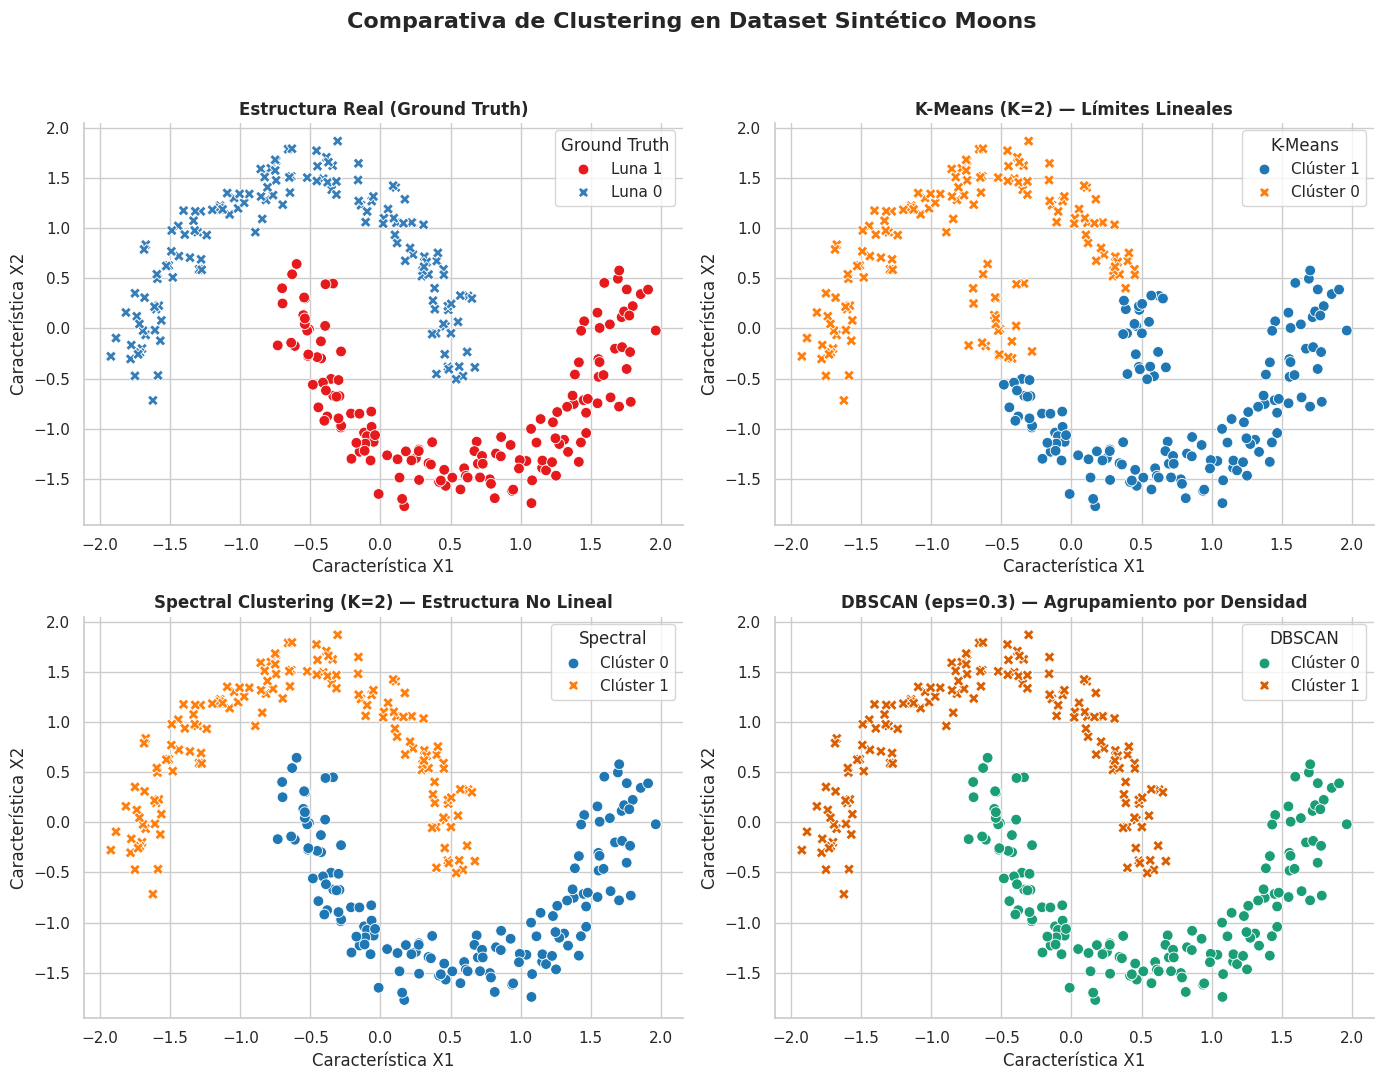

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score
)


# ============================================================
# 1. GENERAR DATASET MOONS
# ============================================================

X, y_true = make_moons(
    n_samples=300,
    noise=0.08,
    random_state=42
)

# Estandarización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ============================================================
# 2. ENTRENAR MODELOS DE CLUSTERING
# ============================================================

# -------------------------
# K-Means
# -------------------------

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels_kmeans = kmeans.fit_predict(X_scaled)


# -------------------------
# DBSCAN
# -------------------------

dbscan = DBSCAN(
    eps=0.30,
    min_samples=5
)

labels_dbscan = dbscan.fit_predict(X_scaled)


# -------------------------
# Spectral Clustering
# -------------------------

spectral = SpectralClustering(
    n_clusters=2,
    affinity='nearest_neighbors',
    random_state=42,
    assign_labels='kmeans'
)

labels_spectral = spectral.fit_predict(X_scaled)


# ============================================================
# 3. ORGANIZAR LOS MODELOS
# ============================================================

models = {
    'K-Means (K=2)': labels_kmeans,
    'DBSCAN (eps=0.3)': labels_dbscan,
    'Spectral Clustering (K=2)': labels_spectral
}


# ============================================================
# 4. MÉTRICAS DE VALIDACIÓN
# ============================================================

results = []

for name, labels in models.items():

    # Número de clusters detectados sin contar ruido
    unique_labels = set(labels)

    n_clusters = len(
        unique_labels - {-1}
    )

    # --------------------------------------------------------
    # MÉTRICAS INTERNAS
    # --------------------------------------------------------

    # Para DBSCAN eliminamos los puntos considerados ruido
    if -1 in labels:

        mask = labels != -1

        X_eval = X_scaled[mask]
        labels_eval = labels[mask]

    else:

        X_eval = X_scaled
        labels_eval = labels


    # Verificar que existan al menos 2 clusters
    if len(set(labels_eval)) > 1:

        sil = silhouette_score(
            X_eval,
            labels_eval
        )

        ch = calinski_harabasz_score(
            X_eval,
            labels_eval
        )

        db = davies_bouldin_score(
            X_eval,
            labels_eval
        )

    else:

        sil = np.nan
        ch = np.nan
        db = np.nan


    # --------------------------------------------------------
    # MÉTRICAS EXTERNAS
    # --------------------------------------------------------

    ari = adjusted_rand_score(
        y_true,
        labels
    )

    nmi = normalized_mutual_info_score(
        y_true,
        labels
    )

    homog = homogeneity_score(
        y_true,
        labels
    )


    # --------------------------------------------------------
    # GUARDAR RESULTADOS
    # --------------------------------------------------------

    results.append({

        'Modelo': name,

        'Clústeres': n_clusters,

        'Silueta (Int) ↑':
            round(sil, 4),

        'Calinski-Harabasz (Int) ↑':
            round(ch, 2),

        'Davies-Bouldin (Int) ↓':
            round(db, 4),

        'ARI (Ext) ↑':
            round(ari, 4),

        'NMI (Ext) ↑':
            round(nmi, 4),

        'Homogeneidad (Ext) ↑':
            round(homog, 4)
    })


# ============================================================
# 5. MOSTRAR RESULTADOS
# ============================================================

df_results = pd.DataFrame(results)

print("=" * 80)
print("RESULTADOS DE CLUSTERING - DATASET SINTÉTICO MOONS")
print("=" * 80)

display(df_results)


# ============================================================
# 6. CREAR DATAFRAME PARA VISUALIZACIÓN
# ============================================================

df_plot = pd.DataFrame(
    X_scaled,
    columns=['X1', 'X2']
)


df_plot['Ground Truth'] = [
    f'Luna {l}'
    for l in y_true
]


df_plot['K-Means'] = [
    f'Clúster {l}'
    for l in labels_kmeans
]


df_plot['DBSCAN'] = [
    f'Clúster {l}'
    if l != -1
    else 'Ruido (-1)'
    for l in labels_dbscan
]


df_plot['Spectral'] = [
    f'Clúster {l}'
    for l in labels_spectral
]


# ============================================================
# 7. CONFIGURACIÓN VISUAL
# ============================================================

sns.set_theme(
    style='whitegrid',
    palette='colorblind'
)


# ============================================================
# 8. CREAR FIGURA 2x2
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 11)
)


fig.suptitle(
    'Comparativa de Clustering en Dataset Sintético Moons',
    fontsize=16,
    fontweight='bold'
)


# ============================================================
# 9. GROUND TRUTH
# ============================================================

sns.scatterplot(
    data=df_plot,
    x='X1',
    y='X2',
    hue='Ground Truth',
    style='Ground Truth',
    ax=axes[0, 0],
    palette='Set1',
    s=60
)

axes[0, 0].set_title(
    'Estructura Real (Ground Truth)',
    fontweight='bold'
)


# ============================================================
# 10. K-MEANS
# ============================================================

sns.scatterplot(
    data=df_plot,
    x='X1',
    y='X2',
    hue='K-Means',
    style='K-Means',
    ax=axes[0, 1],
    palette='tab10',
    s=60
)

axes[0, 1].set_title(
    'K-Means (K=2) — Límites Lineales',
    fontweight='bold'
)


# ============================================================
# 11. SPECTRAL CLUSTERING
# ============================================================

sns.scatterplot(
    data=df_plot,
    x='X1',
    y='X2',
    hue='Spectral',
    style='Spectral',
    ax=axes[1, 0],
    palette='tab10',
    s=60
)

axes[1, 0].set_title(
    'Spectral Clustering (K=2) — Estructura No Lineal',
    fontweight='bold'
)


# ============================================================
# 12. DBSCAN
# ============================================================

sns.scatterplot(
    data=df_plot,
    x='X1',
    y='X2',
    hue='DBSCAN',
    style='DBSCAN',
    ax=axes[1, 1],
    palette='Dark2',
    s=60
)

axes[1, 1].set_title(
    'DBSCAN (eps=0.3) — Agrupamiento por Densidad',
    fontweight='bold'
)


# ============================================================
# 13. ETIQUETAS DE LOS EJES
# ============================================================

for ax in axes.flat:

    ax.set_xlabel(
        'Característica X1'
    )

    ax.set_ylabel(
        'Característica X2'
    )


# ============================================================
# 14. AJUSTAR DISEÑO
# ============================================================

sns.despine()

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()

##CONCLUSION:
###Perfecto Desempeño Real (Métricas Externas = 1.0000):
DBSCAN y Spectral Clustering logran una puntuación ARI = 1.0, NMI = 1.0 y Homogeneidad = 1.0
. Esto significa que descubrieron la estructura real de las dos medias lunas sin ningún error
.
DBSCAN lo logra al conectar observaciones a lo largo de caminos continuos de alta densidad, mientras que Spectral Clustering transforma el espacio mediante la matriz laplaciana de grafos para proyectar las estructuras no lineales en un espacio donde sí son separables
.
###Fallo de K-Means (ARI = 0.4790):
K-Means asume grupos esféricos o convexos y solo soporta límites de separación lineales
. Al intentar dividir las dos lunas entrelazadas con una línea recta, corta ambas figuras por la mitad, mezclando observaciones de ambas clases.

## 1. C. Use el dataset sintético circle y entren los modelos K-means, DBSCAN y SpectralClustering y aplique métricas de validación externa e interna.

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


RESULTADOS DE CLUSTERING - DATASET SINTÉTICO CIRCLES


,Modelo,Clústeres,Silueta (Int) ↑,Calinski-Harabasz (Int) ↑,Davies-Bouldin (Int) ↓,ARI (Ext) ↑,NMI (Ext) ↑,Homogeneidad (Ext) ↑
0,K-Means (K=2),2,0.3532,174.94,1.1752,-0.0033,0.0,0.0
1,DBSCAN (eps=0.35),2,0.1098,0.01,163.2696,1.0000,1.0,1.0
2,Spectral Clustering (K=2),2,0.1098,0.01,163.2696,1.0000,1.0,1.0


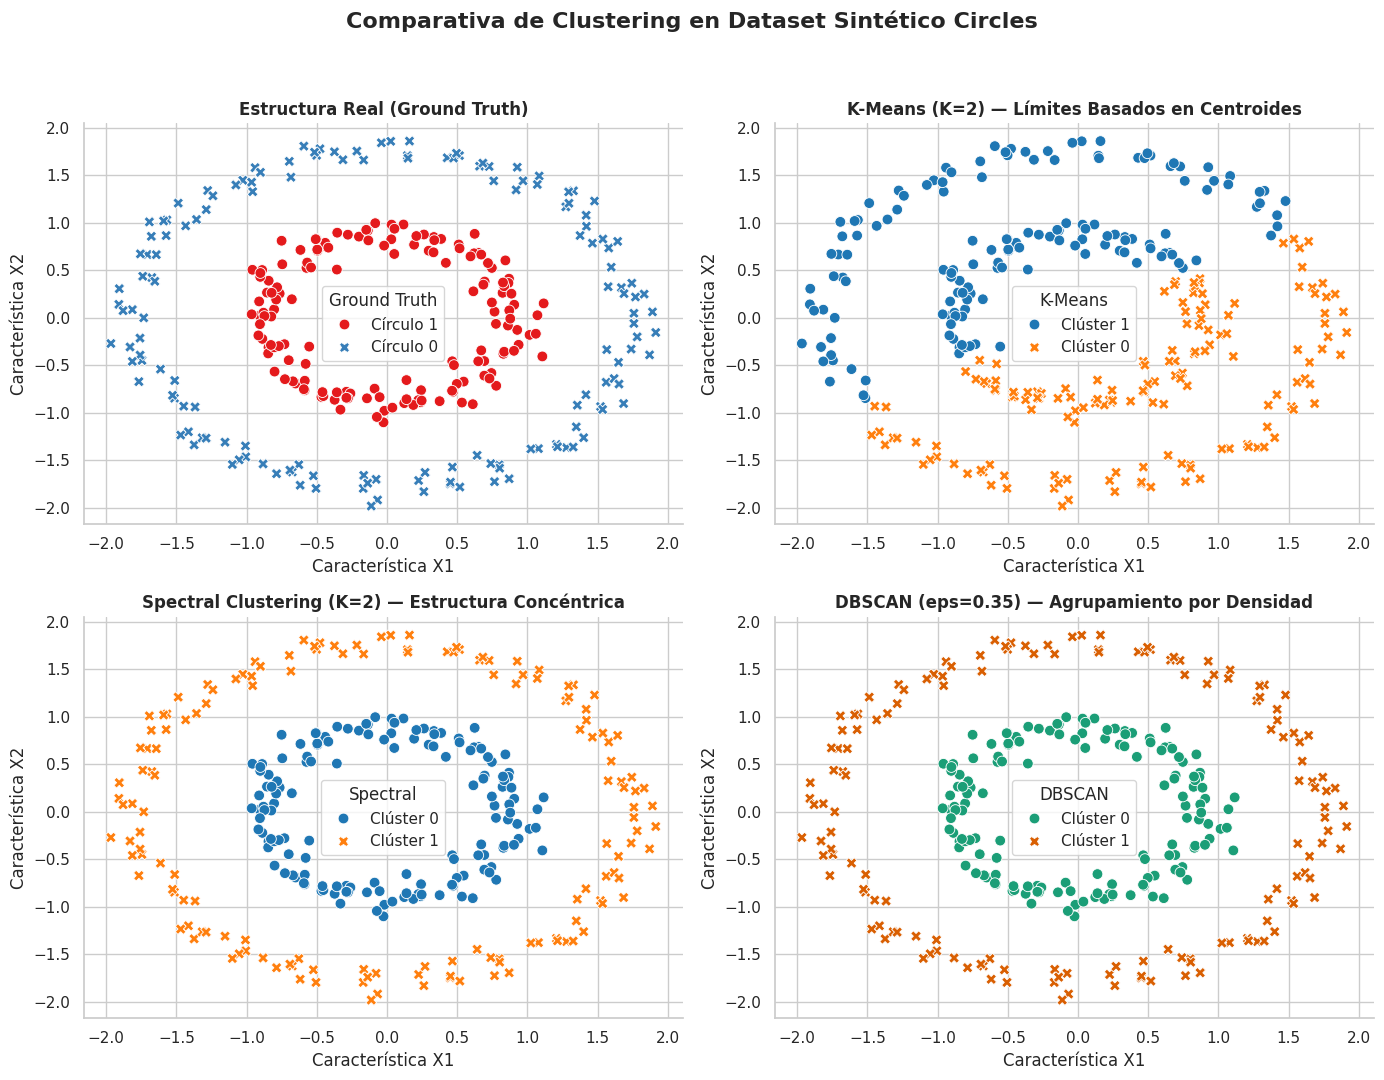

In [8]:
# ==============================================================================
# CLUSTERING EN DATASET SINTÉTICO CIRCLES
# K-MEANS, DBSCAN Y SPECTRAL CLUSTERING
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import (
    KMeans,
    DBSCAN,
    SpectralClustering
)

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score
)


# ==============================================================================
# 1. GENERAR DATASET CIRCLES
# ==============================================================================

X, y_true = make_circles(
    n_samples=300,
    factor=0.5,
    noise=0.05,
    random_state=42
)

# Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ==============================================================================
# 2. ENTRENAR MODELOS DE CLUSTERING
# ==============================================================================

# ------------------------------------------------------------------------------
# K-MEANS
# ------------------------------------------------------------------------------

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels_kmeans = kmeans.fit_predict(X_scaled)


# ------------------------------------------------------------------------------
# DBSCAN
# ------------------------------------------------------------------------------

dbscan = DBSCAN(
    eps=0.35,
    min_samples=5
)

labels_dbscan = dbscan.fit_predict(X_scaled)


# ------------------------------------------------------------------------------
# SPECTRAL CLUSTERING
# ------------------------------------------------------------------------------

spectral = SpectralClustering(
    n_clusters=2,
    affinity='nearest_neighbors',
    random_state=42,
    assign_labels='kmeans'
)

labels_spectral = spectral.fit_predict(X_scaled)


# ==============================================================================
# 3. ORGANIZAR LOS MODELOS
# ==============================================================================

models = {
    'K-Means (K=2)': labels_kmeans,
    'DBSCAN (eps=0.35)': labels_dbscan,
    'Spectral Clustering (K=2)': labels_spectral
}


# ==============================================================================
# 4. CALCULAR MÉTRICAS
# ==============================================================================

results = []

for name, labels in models.items():

    # --------------------------------------------------------------------------
    # Número de clusters
    # --------------------------------------------------------------------------

    unique_labels = set(labels)

    # No contar el -1 de DBSCAN como cluster
    n_clusters = len(
        unique_labels - {-1}
    )


    # --------------------------------------------------------------------------
    # PREPARAR DATOS PARA MÉTRICAS INTERNAS
    # --------------------------------------------------------------------------

    # Si DBSCAN tiene ruido, se excluyen los puntos -1
    # para calcular las métricas internas.

    if -1 in labels:

        mask = labels != -1

        X_eval = X_scaled[mask]
        labels_eval = labels[mask]

    else:

        X_eval = X_scaled
        labels_eval = labels


    # --------------------------------------------------------------------------
    # MÉTRICAS INTERNAS
    # --------------------------------------------------------------------------

    if len(set(labels_eval)) > 1:

        sil = silhouette_score(
            X_eval,
            labels_eval
        )

        ch = calinski_harabasz_score(
            X_eval,
            labels_eval
        )

        db = davies_bouldin_score(
            X_eval,
            labels_eval
        )

    else:

        sil = np.nan
        ch = np.nan
        db = np.nan


    # --------------------------------------------------------------------------
    # MÉTRICAS EXTERNAS
    # --------------------------------------------------------------------------

    ari = adjusted_rand_score(
        y_true,
        labels
    )

    nmi = normalized_mutual_info_score(
        y_true,
        labels
    )

    homog = homogeneity_score(
        y_true,
        labels
    )


    # --------------------------------------------------------------------------
    # GUARDAR RESULTADOS
    # --------------------------------------------------------------------------

    results.append({

        'Modelo': name,

        'Clústeres': n_clusters,

        'Silueta (Int) ↑':
            round(sil, 4),

        'Calinski-Harabasz (Int) ↑':
            round(ch, 2),

        'Davies-Bouldin (Int) ↓':
            round(db, 4),

        'ARI (Ext) ↑':
            round(ari, 4),

        'NMI (Ext) ↑':
            round(nmi, 4),

        'Homogeneidad (Ext) ↑':
            round(homog, 4)
    })


# ==============================================================================
# 5. MOSTRAR RESULTADOS
# ==============================================================================

df_results = pd.DataFrame(results)

print("=" * 85)
print("RESULTADOS DE CLUSTERING - DATASET SINTÉTICO CIRCLES")
print("=" * 85)

display(df_results)


# ==============================================================================
# 6. CREAR DATAFRAME PARA VISUALIZACIÓN
# ==============================================================================

df_plot = pd.DataFrame(
    X_scaled,
    columns=['X1', 'X2']
)


# Ground Truth
df_plot['Ground Truth'] = [
    f'Círculo {l}'
    for l in y_true
]


# K-Means
df_plot['K-Means'] = [
    f'Clúster {l}'
    for l in labels_kmeans
]


# DBSCAN
df_plot['DBSCAN'] = [
    f'Clúster {l}'
    if l != -1
    else 'Ruido (-1)'
    for l in labels_dbscan
]


# Spectral
df_plot['Spectral'] = [
    f'Clúster {l}'
    for l in labels_spectral
]


# ==============================================================================
# 7. CONFIGURACIÓN DEL ESTILO
# ==============================================================================

sns.set_theme(
    style='whitegrid',
    palette='colorblind'
)


# ==============================================================================
# 8. CREAR FIGURA 2x2
# ==============================================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 11)
)


fig.suptitle(
    'Comparativa de Clustering en Dataset Sintético Circles',
    fontsize=16,
    fontweight='bold'
)


# ==============================================================================
# 9. GROUND TRUTH
# ==============================================================================

sns.scatterplot(
    data=df_plot,
    x='X1',
    y='X2',
    hue='Ground Truth',
    style='Ground Truth',
    ax=axes[0, 0],
    palette='Set1',
    s=60
)

axes[0, 0].set_title(
    'Estructura Real (Ground Truth)',
    fontweight='bold'
)


# ==============================================================================
# 10. K-MEANS
# ==============================================================================

sns.scatterplot(
    data=df_plot,
    x='X1',
    y='X2',
    hue='K-Means',
    style='K-Means',
    ax=axes[0, 1],
    palette='tab10',
    s=60
)

axes[0, 1].set_title(
    'K-Means (K=2) — Límites Basados en Centroides',
    fontweight='bold'
)


# ==============================================================================
# 11. SPECTRAL CLUSTERING
# ==============================================================================

sns.scatterplot(
    data=df_plot,
    x='X1',
    y='X2',
    hue='Spectral',
    style='Spectral',
    ax=axes[1, 0],
    palette='tab10',
    s=60
)

axes[1, 0].set_title(
    'Spectral Clustering (K=2) — Estructura Concéntrica',
    fontweight='bold'
)


# ==============================================================================
# 12. DBSCAN
# ==============================================================================

sns.scatterplot(
    data=df_plot,
    x='X1',
    y='X2',
    hue='DBSCAN',
    style='DBSCAN',
    ax=axes[1, 1],
    palette='Dark2',
    s=60
)

axes[1, 1].set_title(
    'DBSCAN (eps=0.35) — Agrupamiento por Densidad',
    fontweight='bold'
)


# ==============================================================================
# 13. ETIQUETAS DE LOS EJES
# ==============================================================================

for ax in axes.flat:

    ax.set_xlabel('Característica X1')
    ax.set_ylabel('Característica X2')


# ==============================================================================
# 14. AJUSTAR DISEÑO
# ==============================================================================

sns.despine()

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()

##CONCLUSIÓN:
###Perfección en Separación No Lineal (ARI = 1.0000):
DBSCAN y Spectral Clustering obtienen puntuaciones perfectas en las métricas externas (ARI = 1.0, NMI = 1.0 y Homogeneidad = 1.0)
- DBSCAN recorre los caminos de alta densidad continua separando sin problemas el anillo exterior del círculo interior
- Spectral Clustering mapea el grafo de afinidad entre vecinos cercanos a un espacio de eigenvectores (Laplaciano), donde los dos anillos concéntricos pasan a ser linealmente separables

### Fracaso Total de K-Means (ARI = -0.0033):
K-Means asigna una puntuación ARI prácticamente igual a 0, lo que equivale a una clasificación completamente aleatoria
- Debido a que K-Means solo soporta límites de separación hiperplanos/lineales y optimiza distancias respecto a un centroide, corta ambos anillos por la mitad en lugar de separar el interior del exterior.
### Incapacidad de las Métricas Internas en Estructuras Anidadas:
- Las métricas de validación interna (Silueta y Calinski-Harabasz) calculan distancias euclidianas directas entre centroides y puntos
- En estructuras concéntricas, el anillo exterior rodea al centro interior, provocando que la distancia promedio entre el anillo exterior y el centro sea muy pequeña en línea recta. Por esta razón, las métricas internas evalúan con mayor puntaje la partición de K-Means (Silueta = 0.3532) a pesar de que es completamente incorrecta biológica/estructuralmente.

## 1. D. Determine qué modelo o modelos son de naturaleza lineal y no lineal, así como los hiper parámetros críticos para el entrenamiento exitoso.

## 1. Clasificación según la Naturaleza del Modelo (Lineal vs. No Lineal)

## Modelos de Naturaleza Lineal

- **K-Means:** Es un algoritmo de naturaleza **lineal**. Divide el espacio mediante fronteras rectas entre los centroides para formar regiones convexas. Por esta razón, como se observó en los experimentos con los datasets *Moons* y *Circles*, puede presentar dificultades cuando los patrones geométricos son curvos o están entrelazados.

- **PCA (Análisis de Componentes Principales):** Es un método de reducción de dimensiones de naturaleza **lineal**. Busca las direcciones que contienen la mayor variabilidad de los datos y proyecta las observaciones sobre esas nuevas dimensiones.

## Modelos de Naturaleza No Lineal

- **Spectral Clustering:** Es un método de naturaleza **no lineal**. Utiliza un grafo de afinidad para representar las relaciones entre los datos y emplea una matriz Laplaciana y sus autovectores para transformar la representación de los datos. Esto permite identificar estructuras complejas y no linealmente separables.

- **DBSCAN:** Es un algoritmo basado en **densidad** que puede identificar grupos con fronteras lineales o no lineales. Agrupa puntos que se encuentran conectados dentro de regiones de alta densidad, por lo que puede adaptarse a diferentes formas geométricas.

- **Isomap y t-SNE:** Son técnicas de reducción de dimensiones pertenecientes a la familia de **Manifold Learning**. A diferencia de PCA, buscan representar relaciones no lineales presentes en los datos.


# 2. Hiperparámetros Críticos para un Entrenamiento Exitoso

## K-Means

### 1. `n_clusters` (K)

Es el **número deseado de clústeres** que se quieren obtener. Es necesario especificarlo antes de ejecutar el algoritmo.

Un valor de K demasiado pequeño puede combinar grupos que deberían estar separados, mientras que un valor demasiado grande puede dividir grupos naturales en varios subgrupos.

**Para seleccionar K adecuadamente** se pueden utilizar:

- Método del **codo**, utilizando la inercia o WSS.
- **Coeficiente de Silueta**.
- Índice de **Calinski-Harabasz**.

### 2. `init`

Define el método utilizado para seleccionar los centroides iniciales.

Una opción recomendada es:

```python
init='k-means++'